# 02 — Training: Layer 4 (Stance) Classifier

| | |
|---|---|
| **Project** | Public Pulse |
| **Pipeline stage** | Layer 4 — Stance (3 classes, post-merge) |
| **Notebook role** | Fine-tuning only |
| **Owner** | Thrithwaka |
| **Upstream input** | `data/splits/layer4/train.csv` (oversampled), `val.csv` (untouched) |
| **Downstream consumer** | `03_evaluation.ipynb` |
| **Base model** | `xlm-roberta-base`, 3-way classification head |
| **Random seed** | 42 |
| **Environment** | Google Colab with GPU runtime, project on Google Drive |

## Purpose

Fine-tunes `xlm-roberta-base` on the merged 3-class Layer 4 taxonomy (`STANCE_CRIT`
[direct+sarcastic merged], `STANCE_NEUT`, `STANCE_SUPP`), using `text_clean` as model
input. Does not touch `test.csv`.

## How to Read This Notebook

No claim of 100% accuracy anywhere in this pipeline. The direct/sarcastic distinction is
deferred to v2 per the documented merge decision in `01_data_preparation.ipynb` — this
is not a surprise to rediscover here, it's a known, carried-forward scope decision.

## 1. Google Colab Setup — Environment & Google Drive

In [ ]:
!pip uninstall -y torchvision torchaudio -q
!pip install -q transformers==4.53.0 datasets accelerate sentencepiece "scikit-learn>=1.4"
print("Install complete. REQUIRED: Runtime -> Restart session, then Runtime -> Run all.")

Install complete. REQUIRED: Runtime -> Restart session, then Runtime -> Run all.


**Stop here and restart the runtime now**, then **Runtime → Run all**.

In [ ]:
import torch
import transformers

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
assert transformers.__version__ == "4.53.0", "Did you Restart session after the install cell?"

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
print("Core imports successful.")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("\nDevice:", device)
if device == "cpu":
    print("WARNING: No GPU detected. Runtime -> Change runtime type -> GPU.")

torch: 2.11.0+cu128
transformers: 4.53.0
Core imports successful.

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/public-pulse-srilanka")
assert PROJECT_ROOT.exists(), f"Project folder not found at {PROJECT_ROOT}."
print("Project root:", PROJECT_ROOT.resolve())

Mounted at /content/drive
Project root: /content/drive/MyDrive/public-pulse-srilanka


In [ ]:
splits_check = PROJECT_ROOT / "data" / "splits" / "layer4"
weights_check = PROJECT_ROOT / "models" / "layer4_stance" / "class_weights.json"
print("train.csv exists:", (splits_check / "train.csv").exists())
print("class_weights.json exists:", weights_check.exists())
if not (splits_check / "train.csv").exists():
    print("WARNING: run the updated 01_data_preparation.ipynb first.")

train.csv exists: True
class_weights.json exists: True


## 2. Setup, Imports & Reproducibility

In [ ]:
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import DataCollatorWithPadding, set_seed
from sklearn.metrics import classification_report, confusion_matrix, f1_score

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
set_seed(RANDOM_STATE)

SPLITS_DIR = PROJECT_ROOT / "data" / "splits" / "layer4"
MODEL_DIR = PROJECT_ROOT / "models" / "layer4_stance"
CHECKPOINTS_DIR = MODEL_DIR / "checkpoints"
RUN_OUTPUT_DIR = MODEL_DIR / "_training_run"
RESULTS_TRAINING_DIR = PROJECT_ROOT / "results" / "training_curves"
RESULTS_CM_DIR = PROJECT_ROOT / "results" / "confusion_matrices"

for d in [CHECKPOINTS_DIR, RUN_OUTPUT_DIR, RESULTS_TRAINING_DIR, RESULTS_CM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "xlm-roberta-base"
MAX_SEQ_LENGTH = 256
EXPECTED_LABEL_COUNT = 3  # post-merge: STANCE_CRIT, STANCE_NEUT, STANCE_SUPP

## 3. Load Prepared Data

Model input is `text_clean`, not `text_raw`. `is_sarcastic` is guaranteed absent from
these files by the data-prep notebook's column-scoping assertions.

In [ ]:
train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df = pd.read_csv(SPLITS_DIR / "val.csv")

LAYER4_LABELS = sorted(train_df["layer4_stance_label"].unique())

print(f"Train: {len(train_df)} rows (oversampled)")
print(f"Val:   {len(val_df)} rows (untouched)")
print("Classes found:", LAYER4_LABELS)
print(train_df["layer4_stance_label"].value_counts())

assert "text_clean" in train_df.columns, "text_clean missing -- run the updated 01_data_preparation.ipynb"
assert train_df["layer4_stance_label"].isna().sum() == 0
assert len(LAYER4_LABELS) == EXPECTED_LABEL_COUNT, (
    f"Expected {EXPECTED_LABEL_COUNT} classes (post-merge), found {len(LAYER4_LABELS)}: {LAYER4_LABELS}"
)
assert "is_sarcastic" not in train_df.columns, "is_sarcastic must not be present -- leakage risk"
for leaked_col in ["layer1_utility_label", "layer2_topic_label", "layer3_subissue_label"]:
    assert leaked_col not in train_df.columns, f"{leaked_col} should not be present"
print("\nUpstream data contract verified: 3 classes, text_clean present, no leakage.")

Train: 5667 rows (oversampled)
Val:   1153 rows (untouched)
Classes found: ['STANCE_CRIT', 'STANCE_NEUT', 'STANCE_SUPP']
layer4_stance_label
STANCE_CRIT    3797
STANCE_NEUT    1370
STANCE_SUPP     500
Name: count, dtype: int64

Upstream data contract verified: 3 classes, text_clean present, no leakage.


## 4. Label Encoding

In [ ]:
label2id = {label: idx for idx, label in enumerate(LAYER4_LABELS)}
id2label = {idx: label for label, idx in label2id.items()}

with open(MODEL_DIR / "label_map.json", "w") as f:
    json.dump(label2id, f, indent=2)

print("Label map:", label2id)
train_df["label"] = train_df["layer4_stance_label"].map(label2id)
val_df["label"] = val_df["layer4_stance_label"].map(label2id)

Label map: {'STANCE_CRIT': 0, 'STANCE_NEUT': 1, 'STANCE_SUPP': 2}


## 5. Tokenization & Dataset Construction (on `text_clean`)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text_clean"], truncation=True, max_length=MAX_SEQ_LENGTH)

train_dataset = Dataset.from_pandas(train_df[["text_clean", "label"]].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[["text_clean", "label"]].reset_index(drop=True))

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
print(train_dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5667 [00:00<?, ? examples/s]

Map:   0%|          | 0/1153 [00:00<?, ? examples/s]

Dataset({
    features: ['text_clean', 'label', 'input_ids', 'attention_mask'],
    num_rows: 5667
})


## 6. Load Class Weights

In [ ]:
with open(MODEL_DIR / "class_weights.json") as f:
    class_weights_dict = json.load(f)

print("Loaded class weights:")
for label, weight in sorted(class_weights_dict.items(), key=lambda x: -x[1]):
    print(f"  {label:15s} {weight}")

class_weights_ordered = [class_weights_dict[id2label[i]] for i in range(len(LAYER4_LABELS))]
class_weights_tensor = torch.tensor(class_weights_ordered, dtype=torch.float32).to(device)

Loaded class weights:
  STANCE_SUPP     3.778
  STANCE_NEUT     1.3788
  STANCE_CRIT     0.4975


## 7. Model Initialization

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LAYER4_LABELS), id2label=id2label, label2id=label2id,
)
model.to(device)
print(f"Model on {device}, {model.num_parameters():,} parameters, {len(LAYER4_LABELS)}-class head")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model on cuda, 278,045,955 parameters, 3-class head


## 8. Weighted-Loss Trainer

In [ ]:
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, len(LAYER4_LABELS)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

## 9. Evaluation Metrics

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    report = classification_report(
        labels, predictions, labels=list(range(len(LAYER4_LABELS))),
        target_names=LAYER4_LABELS, output_dict=True, zero_division=0,
    )
    metrics = {"accuracy": report["accuracy"], "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0)}
    for label in LAYER4_LABELS:
        metrics[f"f1_{label}"] = report[label]["f1-score"]
    return metrics

## 10. Training Configuration

In [ ]:
training_args = TrainingArguments(
    output_dir=str(RUN_OUTPUT_DIR),
    eval_strategy="epoch", save_strategy="epoch", logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    num_train_epochs=4, weight_decay=0.01, warmup_ratio=0.1,
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    save_total_limit=2, fp16=(device == "cuda"), seed=RANDOM_STATE,
    report_to="none", dataloader_pin_memory=(device == "cuda"),
)

trainer = WeightedLossTrainer(
    model=model, args=training_args,
    train_dataset=train_dataset, eval_dataset=val_dataset,
    data_collator=data_collator, compute_metrics=compute_metrics,
)

## 11. Train

In [ ]:
train_result = trainer.train()
print("Training complete.")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Stance Crit,F1 Stance Neut,F1 Stance Supp
1,0.813400,0.614189,0.829141,0.695745,0.884810,0.780656,0.421769
2,0.443200,0.429730,0.907199,0.821915,0.940086,0.869410,0.656250
3,0.298500,0.323097,0.921075,0.855504,0.946970,0.890728,0.728814
4,0.192100,0.358974,0.926279,0.864946,0.950346,0.896667,0.747826


Training complete.
TrainOutput(global_step=1420, training_loss=0.43680316763864435, metrics={'train_runtime': 407.6544, 'train_samples_per_second': 55.606, 'train_steps_per_second': 3.483, 'total_flos': 1453294115485758.0, 'train_loss': 0.43680316763864435, 'epoch': 4.0})


## 12. Training Curves

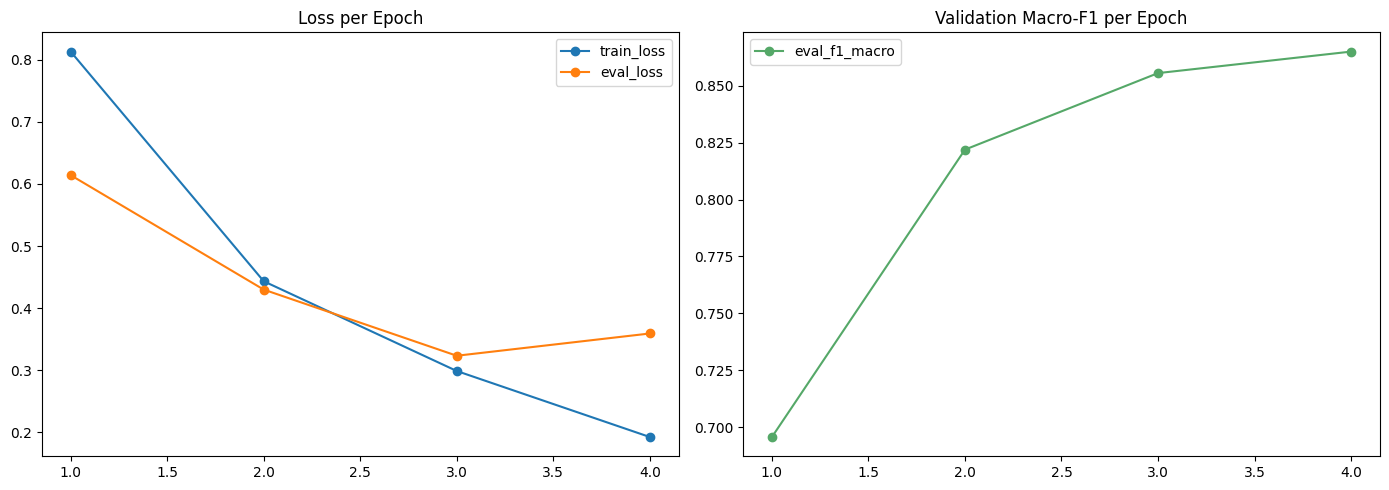

In [ ]:
log_history = trainer.state.log_history
train_loss = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e]
eval_loss = [(e["epoch"], e["eval_loss"]) for e in log_history if "eval_loss" in e]
eval_f1 = [(e["epoch"], e["eval_f1_macro"]) for e in log_history if "eval_f1_macro" in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if train_loss: axes[0].plot(*zip(*train_loss), label="train_loss", marker="o")
if eval_loss: axes[0].plot(*zip(*eval_loss), label="eval_loss", marker="o")
axes[0].set_title("Loss per Epoch"); axes[0].legend()
if eval_f1: axes[1].plot(*zip(*eval_f1), label="eval_f1_macro", marker="o", color="#55A868")
axes[1].set_title("Validation Macro-F1 per Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS_TRAINING_DIR / "layer4_training_curves.png", dpi=150)
plt.show()

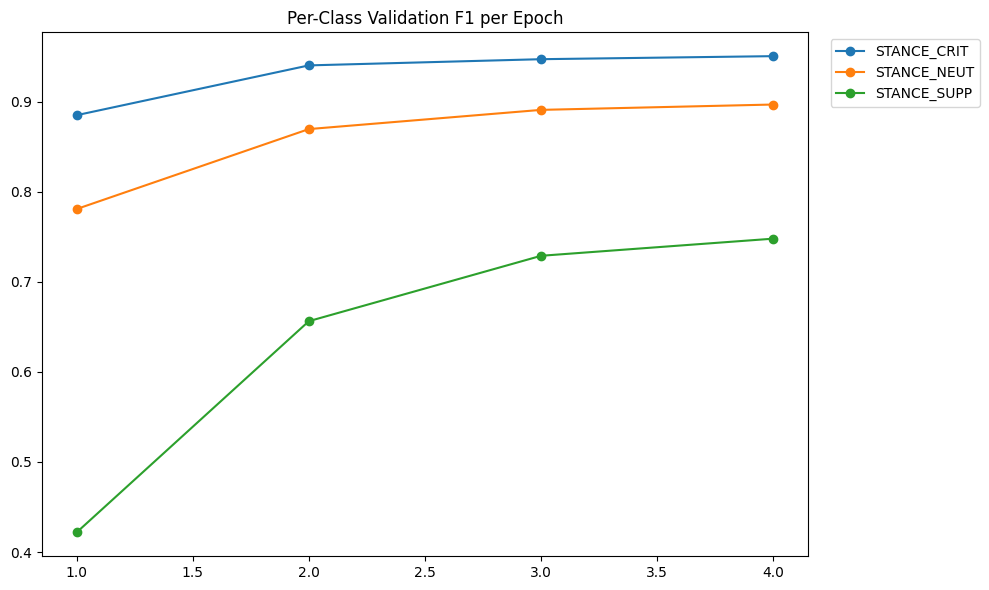

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for label in LAYER4_LABELS:
    key = f"eval_f1_{label}"
    series = [(e["epoch"], e[key]) for e in log_history if key in e]
    if series:
        ax.plot(*zip(*series), label=label, marker="o")
ax.set_title("Per-Class Validation F1 per Epoch")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS_TRAINING_DIR / "layer4_per_class_f1_curves.png", dpi=150)
plt.show()

## 13. Save the Promoted Checkpoint

In [ ]:
best_model_dir = CHECKPOINTS_DIR / "best_model"
best_model_dir.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(best_model_dir))
tokenizer.save_pretrained(str(best_model_dir))

metadata = {
    "base_model": MODEL_NAME, "num_labels": len(LAYER4_LABELS),
    "labels": LAYER4_LABELS, "max_seq_length": MAX_SEQ_LENGTH,
    "model_input_column": "text_clean",
    "best_metric": "f1_macro", "best_metric_value": trainer.state.best_metric,
    "class_weights_used": class_weights_dict,
    "taxonomy_note": "3-class merged taxonomy (STANCE_CRIT_DIR+STANCE_CRIT_SARC -> STANCE_CRIT). "
                       "Direct/sarcastic distinction deferred to v2 -- documented scope decision, "
                       "see 01_data_preparation.ipynb Section 9.",
    "random_seed": RANDOM_STATE, "train_rows": len(train_df), "val_rows": len(val_df),
}
with open(MODEL_DIR / "training_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved to:", best_model_dir.resolve())
print("Best validation macro-F1:", trainer.state.best_metric)

Saved to: /content/drive/MyDrive/public-pulse-srilanka/models/layer4_stance/checkpoints/best_model
Best validation macro-F1: 0.8649461493849765


## 14. Validation Set Sanity Check

Not the final evaluation.

In [ ]:
val_predictions = trainer.predict(val_dataset)
val_preds = np.argmax(val_predictions.predictions, axis=-1)
val_labels = val_predictions.label_ids

print(classification_report(val_labels, val_preds, labels=list(range(len(LAYER4_LABELS))), target_names=LAYER4_LABELS, zero_division=0))

              precision    recall  f1-score   support

 STANCE_CRIT       0.97      0.93      0.95       813
 STANCE_NEUT       0.88      0.91      0.90       294
 STANCE_SUPP       0.62      0.93      0.75        46

    accuracy                           0.93      1153
   macro avg       0.82      0.93      0.86      1153
weighted avg       0.93      0.93      0.93      1153



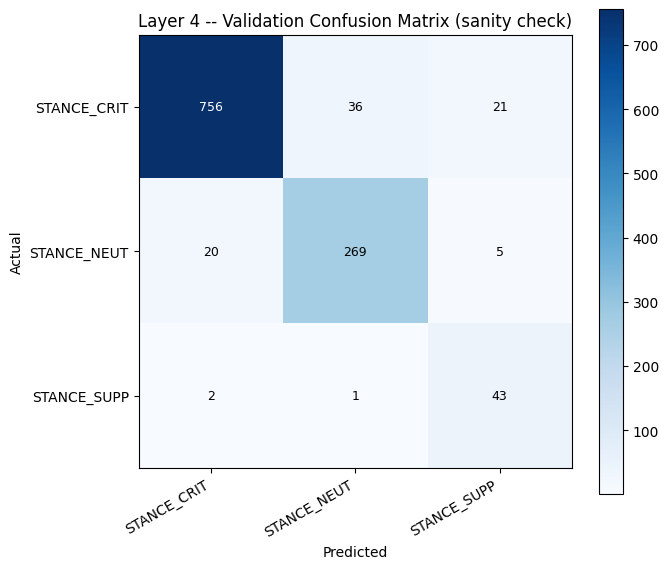

In [ ]:
cm = confusion_matrix(val_labels, val_preds, labels=list(range(len(LAYER4_LABELS))))
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(LAYER4_LABELS))); ax.set_xticklabels(LAYER4_LABELS, rotation=30, ha="right")
ax.set_yticks(range(len(LAYER4_LABELS))); ax.set_yticklabels(LAYER4_LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Layer 4 -- Validation Confusion Matrix (sanity check)")
for i in range(len(LAYER4_LABELS)):
    for j in range(len(LAYER4_LABELS)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i,j]>cm.max()/2 else "black", fontsize=9)
plt.colorbar(im)
plt.tight_layout()
plt.savefig(RESULTS_CM_DIR / "layer4_validation_confusion_matrix.png", dpi=150)
plt.show()

## 15. Notebook Summary

### What was done
1. Colab environment configured (torchvision conflict avoided, transformers pinned, Drive mounted)
2. Loaded oversampled train + untouched val data, verified `text_clean` present, 3-class
   contract holds, `is_sarcastic` confirmed absent
3. Loaded correctly-computed class weights, built a `WeightedLossTrainer`
4. Fine-tuned `xlm-roberta-base` (3-way head) on `text_clean`
5. Saved checkpoint + metadata documenting the taxonomy merge decision

### Key results
[Fill in after running: best validation macro-F1, per-class F1 for STANCE_CRIT/NEUT/SUPP.]

## 16. Handover Notes — For `03_evaluation.ipynb`

**Load:** checkpoint from `models/layer4_stance/checkpoints/best_model/`, label map
from `models/layer4_stance/label_map.json` (3 classes — `STANCE_CRIT` is merged
direct+sarcastic, `NULL` excluded).

**Evaluate against `data/splits/layer4/test.csv` using `text_clean`, not `text_raw`.**

**For the project presentation:** this is a good place to explicitly state the v1/v2
scope: v1 ships reliable 3-class stance detection; v2 goal is reinstating the
direct/sarcastic distinction once a targeted, multi-annotator sarcasm collection effort
is done (motivated by the 71.2%-vs-13% positive-emoji finding in
`01_data_preparation.ipynb`, which shows the sarcasm signal exists even though this
round's label volume didn't support training it directly).